In [ ]:
# ============================================================
# CELL 1 — Install Dependencies
# ============================================================
!pip install -q timm albumentations onnx onnxruntime opencv-python-headless seaborn
print('✅ All packages installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 95.4 MB/s eta 0:00:00
✅ All packages installed!


In [ ]:
# ============================================================
# CELL 2 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# ── YOUR EXACT PATHS (matching your Google Drive structure)
BASE_DIR  = '/content/drive/MyDrive/terrain_classification/'
IMAGE_DIR = BASE_DIR + 'images/'          # contains: Grass Terrain/, Marshy Terrain/, Rocky Terrain/, Sandy Terrain/
CSV_PATH  = BASE_DIR + 'terrain_dataset.csv'

# ── Verify folders exist
FOLDER_NAMES = ['Grass Terrain', 'Marshy Terrain', 'Rocky Terrain', 'Sandy Terrain']
print('\n📂 Checking your dataset folders...')
for f in FOLDER_NAMES:
    path  = IMAGE_DIR + f + '/'
    if os.path.exists(path):
        count = len([x for x in os.listdir(path)
                     if x.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
        print(f'  ✅ {f}: {count} images')
    else:
        print(f'  ❌ NOT FOUND: {path}')

# ── Verify CSV
if os.path.exists(CSV_PATH):
    print(f'\n✅ CSV found: {CSV_PATH}')
else:
    print(f'\n❌ CSV NOT FOUND: {CSV_PATH}')

Mounted at /content/drive

📂 Checking your dataset folders...
  ✅ Grass Terrain: 73 images
  ✅ Marshy Terrain: 52 images
  ✅ Rocky Terrain: 81 images
  ✅ Sandy Terrain: 78 images

✅ CSV found: /content/drive/MyDrive/terrain_classification/terrain_dataset.csv


In [ ]:
# ============================================================
# CELL 3 — Imports & Global Config
# ============================================================
import cv2, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import deque

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')

# ── Map folder names → clean class labels
FOLDER_TO_CLASS = {
    'Grass Terrain':  'Grass',
    'Marshy Terrain': 'Marshy',
    'Rocky Terrain':  'Rock',
    'Sandy Terrain':  'Sandy',
}
CLASSES      = ['Grass', 'Marshy', 'Rock', 'Sandy']
FOLDER_NAMES = list(FOLDER_TO_CLASS.keys())

# ── Sensor columns from your CSV
SENSOR_COLS = ['Accel_X','Accel_Y','Accel_Z',
               'Gyro_X','Gyro_Y','Gyro_Z',
               'Vibration','Suspension_Stiffness','Suspension_Damping']

CONFIG = {
    'image_dir':   IMAGE_DIR,
    'csv_path':    CSV_PATH,
    'image_size':  224,
    'batch_size':  32,
    'num_workers': 2,
    'epochs':      30,
    'lr':          3e-4,
    'weight_decay':1e-4,
    'patience':    8,
    'dropout':     0.5,
    'backbone':    'efficientnet_b4',
    'device':      'cuda' if torch.cuda.is_available() else 'cpu',
    'save_dir':    '/content/checkpoints/',
    'log_dir':     '/content/logs/',
    'results_dir': '/content/results/',
}

for d in [CONFIG['save_dir'], CONFIG['log_dir'], CONFIG['results_dir']]:
    os.makedirs(d, exist_ok=True)

DEVICE = CONFIG['device']
print(f'✅ Device : {DEVICE.upper()}')
print(f'✅ Classes: {CLASSES}')
print(f'✅ Sensors: {SENSOR_COLS}')

✅ Device : CUDA
✅ Classes: ['Grass', 'Marshy', 'Rock', 'Sandy']
✅ Sensors: ['Accel_X', 'Accel_Y', 'Accel_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Vibration', 'Suspension_Stiffness', 'Suspension_Damping']


In [ ]:
# ============================================================
# CELL 4 — Load & Preview CSV
# ============================================================
df_csv = pd.read_csv(CSV_PATH)
print(f'✅ CSV loaded: {df_csv.shape[0]} rows × {df_csv.shape[1]} columns')
print(f'\nColumns: {list(df_csv.columns)}')
print(f'\nTerrain labels in CSV:')
print(df_csv['Terrain_Label'].value_counts())
print(f'\nFirst 3 rows:')
df_csv.head(3)

✅ CSV loaded: 1525 rows × 12 columns

Columns: ['Timestamp', 'Image_Path', 'Accel_X', 'Accel_Y', 'Accel_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Vibration', 'Terrain_Label', 'Suspension_Stiffness', 'Suspension_Damping']

Terrain labels in CSV:
Terrain_Label
gravel         209
mud            200
grass          197
slope          192
water_patch    191
crop_rows      185
sand           176
dry_soil       175
Name: count, dtype: int64

First 3 rows:


,Timestamp,Image_Path,Accel_X,Accel_Y,Accel_Z,Gyro_X,Gyro_Y,Gyro_Z,Vibration,Terrain_Label,Suspension_Stiffness,Suspension_Damping
0,2024-07-25 10:00:00,/images/img_000.jpg,0.049671,0.108875,9.525665,-0.002215,-0.005879,0.008445,0.631726,crop_rows,120,0.65
1,2024-07-25 10:00:01,/images/img_001.jpg,-0.013826,0.188459,9.658112,-0.011770,0.002306,0.011017,0.546439,water_patch,140,0.75
2,2024-07-25 10:00:02,/images/img_002.jpg,0.064769,0.154324,9.742290,0.018205,-0.011334,0.004920,0.699083,mud,80,0.45


In [ ]:
# ============================================================
# CELL 5 — Hand-Crafted Image Feature Extractor
# ============================================================
class HandCraftedFeatureExtractor:
    """Extracts texture + color + frequency + physics proxy features."""

    def extract_texture(self, gray):
        feats = []
        for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
            for sigma in [1, 3, 5]:
                k = cv2.getGaborKernel((21,21), sigma, theta, 10.0, 0.5, 0)
                f = cv2.filter2D(gray, cv2.CV_64F, k)
                feats.extend([f.mean(), f.std()])
        lap = cv2.Laplacian(gray, cv2.CV_64F)
        feats.extend([lap.mean(), lap.std(), np.abs(lap).mean()])
        edges = cv2.Canny(gray, 50, 150)
        feats.append(edges.sum() / edges.size)
        sx  = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sy  = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(sx**2 + sy**2)
        feats.extend([mag.mean(), mag.std()])
        return np.array(feats)   # 28

    def extract_color(self, img):
        feats = []
        for c in range(3):
            ch = img[:,:,c].astype(np.float32)
            feats.extend([ch.mean(), ch.std(),
                          np.percentile(ch,25), np.percentile(ch,75)])
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
        for c in range(3): feats.extend([hsv[:,:,c].mean(), hsv[:,:,c].std()])
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)
        for c in range(3): feats.extend([lab[:,:,c].mean(), lab[:,:,c].std()])
        return np.array(feats)   # 30

    def extract_frequency(self, gray):
        fft  = np.fft.fftshift(np.fft.fft2(gray.astype(np.float32)))
        mag  = np.log1p(np.abs(fft))
        h,w  = mag.shape
        cy,cx = h//2, w//2
        Y,X  = np.ogrid[:h,:w]
        dist = np.sqrt((X-cx)**2 + (Y-cy)**2)
        bands, prev = [], 0
        for r in [10,30,60,100]:
            mask = (dist>=prev)&(dist<r)
            bands.append(mag[mask].mean() if mask.sum()>0 else 0.0)
            prev = r
        bands.append(mag[dist>=100].mean())
        dct = cv2.dct(gray.astype(np.float32)/255.0)
        return np.array(bands + [dct[:8,:8].std(), dct.mean()])  # 7

    def extract_physics(self, img, gray):
        r,g,b = [img[:,:,i].astype(np.float32) for i in range(3)]
        eps   = 1e-6
        ndvi  = (g-r)/(g+r+eps)
        blue  = b/(r+g+b+eps)
        hist  = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256]*3).flatten()
        hist /= hist.sum()+eps
        ent   = -np.sum(hist[hist>0]*np.log2(hist[hist>0]+eps))
        lv    = (cv2.blur(gray.astype(np.float32)**2,(5,5))
                 - cv2.blur(gray.astype(np.float32),(5,5))**2)
        return np.array([ndvi.mean(), ndvi.std(), blue.mean(), ent, lv.std()])  # 5

    def extract_all_from_array(self, img_bgr):
        """Extract features directly from a BGR numpy array (no file I/O)."""
        img  = cv2.resize(img_bgr, (224,224))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        return np.concatenate([
            self.extract_texture(gray),
            self.extract_color(img),
            self.extract_frequency(gray),
            self.extract_physics(img, gray)
        ])  # 70 image features

print('✅ HandCraftedFeatureExtractor defined (70 image features)')

✅ HandCraftedFeatureExtractor defined (70 image features)


In [ ]:
# ============================================================
# CELL 6 — Build Master Dataset (Images + CSV Sensor Data)
# ============================================================
from tqdm.notebook import tqdm

hcf_ext    = HandCraftedFeatureExtractor()
le         = LabelEncoder()
le.fit(CLASSES)

# ── Build a lookup: image filename → sensor row from CSV
# CSV Image_Path column looks like: /images/img_001.jpg
# We extract just the filename for matching
df_csv['img_filename'] = df_csv['Image_Path'].apply(
    lambda x: os.path.basename(str(x)))

# Normalise CSV terrain labels to match our CLASSES
LABEL_MAP = {
    'grass':      'Grass',
    'crop_rows':  'Grass',    # treat crop rows as grass-like
    'dry_soil':   'Sandy',
    'sand':       'Sandy',
    'gravel':     'Rock',
    'slope':      'Rock',
    'mud':        'Marshy',
    'water_path': 'Marshy',
    'water_pat':  'Marshy',
}
df_csv['class_label'] = df_csv['Terrain_Label'].str.strip().str.lower().map(LABEL_MAP)
df_csv = df_csv.dropna(subset=['class_label'])  # drop unmapped

sensor_lookup = dict(zip(df_csv['img_filename'],
                         df_csv[SENSOR_COLS + ['class_label']].values))

print(f'✅ CSV sensor lookup ready: {len(sensor_lookup)} entries')
print(f'   Mapped class distribution:')
print(df_csv['class_label'].value_counts())

# ── Scan image folders
all_paths, all_labels, all_img_feats, all_sensor_feats = [], [], [], []
sensor_scaler = StandardScaler()
raw_sensor_rows = []

print('\n📂 Extracting image features (this takes a few minutes)...')
for folder_name, class_label in FOLDER_TO_CLASS.items():
    folder = Path(IMAGE_DIR) / folder_name
    if not folder.exists():
        print(f'  ⚠️  Skipping missing folder: {folder}')
        continue
    img_files = [p for p in folder.iterdir()
                 if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}]
    print(f'  📁 {folder_name}: {len(img_files)} images → class: {class_label}')

    for p in tqdm(img_files, desc=f'  {class_label}', leave=False):
        bgr = cv2.imread(str(p))
        if bgr is None: continue

        # Image features
        img_feat = hcf_ext.extract_all_from_array(bgr)

        # Sensor features: use CSV lookup or zeros if not found
        fname = p.name
        if fname in sensor_lookup:
            row = sensor_lookup[fname]
            sensor_feat = np.array(row[:len(SENSOR_COLS)], dtype=np.float32)
        else:
            sensor_feat = np.zeros(len(SENSOR_COLS), dtype=np.float32)

        all_paths.append(str(p))
        all_labels.append(int(le.transform([class_label])[0]))
        all_img_feats.append(img_feat)
        raw_sensor_rows.append(sensor_feat)

# Normalise sensor features
all_img_feats    = np.array(all_img_feats,    dtype=np.float32)
raw_sensor_rows  = np.array(raw_sensor_rows,  dtype=np.float32)
all_sensor_feats = sensor_scaler.fit_transform(raw_sensor_rows).astype(np.float32)

# Concatenate image + sensor features
all_features = np.concatenate([all_img_feats, all_sensor_feats], axis=1)
FEAT_DIM     = all_features.shape[1]

print(f'\n✅ Total samples     : {len(all_paths)}')
print(f'✅ Image feature dim : {all_img_feats.shape[1]}')
print(f'✅ Sensor feature dim: {all_sensor_feats.shape[1]}')
print(f'✅ Total feature dim : {FEAT_DIM}')

✅ CSV sensor lookup ready: 1334 entries
   Mapped class distribution:
class_label
Rock      401
Grass     382
Sandy     351
Marshy    200
Name: count, dtype: int64

📂 Extracting image features (this takes a few minutes)...
  📁 Grass Terrain: 73 images → class: Grass


  Grass:   0%|          | 0/73 [00:00<?, ?it/s]

  ⚠️  Skipping missing folder: /content/drive/MyDrive/terrain_classification/images/Marshy Terrain
  ⚠️  Skipping missing folder: /content/drive/MyDrive/terrain_classification/images/Rocky Terrain
  ⚠️  Skipping missing folder: /content/drive/MyDrive/terrain_classification/images/Sandy Terrain

✅ Total samples     : 7
✅ Image feature dim : 66
✅ Sensor feature dim: 9
✅ Total feature dim : 75


In [ ]:
# ============================================================
# CELL 7 — Dataset Class + DataLoaders
# ============================================================
def get_transforms(phase):
    sz = CONFIG['image_size']
    if phase == 'train':
        return A.Compose([
            A.Resize(sz, sz),
            A.RandomRotate90(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(0.3, 0.3, p=0.6),
            A.HueSaturationValue(20, 30, 20, p=0.4),
            A.GaussNoise(var_limit=(10,50), p=0.3),
            A.GaussianBlur(blur_limit=(3,7), p=0.3),
            A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.2),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(sz, sz),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

class TerrainDataset(Dataset):
    def __init__(self, paths, labels, features, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.features  = features
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.paths[idx]).convert('RGB'))
        if self.transform:
            img = self.transform(image=img)['image']
        feat  = torch.FloatTensor(self.features[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, feat, label

# ── Stratified train / val / test split
idx    = np.arange(len(all_paths))
tr, tmp = train_test_split(idx, test_size=0.30,
                            stratify=all_labels, random_state=42)
vl, ts  = train_test_split(tmp, test_size=0.50,
                            stratify=[all_labels[i] for i in tmp],
                            random_state=42)

def make_loader(split, phase):
    ds = TerrainDataset(
        [all_paths[i]  for i in split],
        [all_labels[i] for i in split],
        all_features[split],
        transform=get_transforms(phase)
    )
    return DataLoader(ds, batch_size=CONFIG['batch_size'],
                      shuffle=(phase=='train'),
                      num_workers=CONFIG['num_workers'],
                      pin_memory=True)

train_loader = make_loader(tr, 'train')
val_loader   = make_loader(vl, 'val')
test_loader  = make_loader(ts, 'test')

print(f'✅ Train: {len(tr)}  Val: {len(vl)}  Test: {len(ts)}')
print(f'✅ Feature dim: {FEAT_DIM}  (image={all_img_feats.shape[1]}, sensor={all_sensor_feats.shape[1]})')

✅ Train: 4  Val: 1  Test: 2
✅ Feature dim: 75  (image=66, sensor=9)


In [ ]:
# ============================================================
# CELL 8 — Hybrid Model (CNN + Image Features + Sensor Features)
# ============================================================
class SensorBranch(nn.Module):
    """MLP for the 9 sensor columns from your CSV."""
    def __init__(self, in_dim=9, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, out_dim), nn.BatchNorm1d(out_dim), nn.ReLU()
        )
    def forward(self, x): return self.net(x)

class ImageFeatureBranch(nn.Module):
    """MLP for the 70 hand-crafted image features."""
    def __init__(self, in_dim=70, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, out_dim), nn.BatchNorm1d(out_dim), nn.ReLU()
        )
    def forward(self, x): return self.net(x)

class TerrainModel(nn.Module):
    """
    3-branch fusion:
      Branch A: EfficientNet-B4 CNN backbone (deep image features)
      Branch B: Hand-crafted image features MLP
      Branch C: Sensor data MLP (Accel, Gyro, Vibration, Suspension)
    """
    def __init__(self, num_classes=4, img_feat_dim=70,
                 sensor_dim=9, backbone='efficientnet_b4', dropout=0.5):
        super().__init__()
        self.img_feat_dim = img_feat_dim # Store img_feat_dim
        self.sensor_dim = sensor_dim     # Store sensor_dim
        # CNN branch
        self.backbone = timm.create_model(
            backbone, pretrained=True, num_classes=0, global_pool='avg')
        cnn_out = self.backbone.num_features
        self.cnn_proj = nn.Sequential(
            nn.Linear(cnn_out, 512), nn.BatchNorm1d(512),
            nn.ReLU(), nn.Dropout(0.4))

        # Image feature branch
        self.img_branch = ImageFeatureBranch(self.img_feat_dim, 128)

        # Sensor branch
        self.sensor_branch = SensorBranch(self.sensor_dim, 64)

        # Fusion gate (attention over 3 branches)
        fused = 512 + 128 + 64  # = 704
        self.gate = nn.Sequential(nn.Linear(fused, 3), nn.Softmax(dim=1))

        self.fusion = nn.Sequential(
            nn.Linear(fused, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),   nn.BatchNorm1d(256), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256, num_classes))
        self.temp = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, img, combined_feat):
        # Split combined feature vector → image feats + sensor feats
        img_f    = combined_feat[:, :self.img_feat_dim] # Use stored dim
        sensor_f = combined_feat[:, self.img_feat_dim:] # Use stored dim

        c = self.cnn_proj(self.backbone(img))      # (B, 512)
        h = self.img_branch(img_f)                 # (B, 128)
        s = self.sensor_branch(sensor_f)           # (B, 64)

        raw   = torch.cat([c, h, s], dim=1)        # (B, 704)
        gates = self.gate(raw)                     # (B, 3)
        fused = torch.cat([
            c * gates[:,0:1],
            h * gates[:,1:2],
            s * gates[:,2:3]
        ], dim=1)

        out = self.head(self.fusion(fused))
        return out, out / self.temp.clamp(min=0.1)

    def mc_predict(self, img, feat, n=10):
        # Set model to evaluation mode, but enable dropout layers for MC dropout
        self.eval()
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train() # Enable dropout layers only

        probs = []
        with torch.no_grad():
            for _ in range(n):
                _, cal = self(img, feat)
                probs.append(F.softmax(cal, dim=-1))

        # Restore original eval state for all layers
        self.eval()

        stack   = torch.stack(probs)
        mean_p  = stack.mean(0)
        entropy = -(mean_p * torch.log(mean_p+1e-9)).sum(-1)
        conf, pred = mean_p.max(-1)
        return pred, conf, entropy, mean_p

model = TerrainModel(
    num_classes=4,
    img_feat_dim=all_img_feats.shape[1],
    sensor_dim=all_sensor_feats.shape[1],
    backbone=CONFIG['backbone']
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f'✅ Model ready | Parameters: {total:,}')
print(f'   CNN branch    : EfficientNet-B4 → 512 dims')
print(f'   Image branch  : {all_img_feats.shape[1]} → 128 dims')
print(f'   Sensor branch : {all_sensor_feats.shape[1]} → 64 dims')
print(f'   Fusion total  : 704 → 256 → 4 classes')

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

✅ Model ready | Parameters: 19,020,496
   CNN branch    : EfficientNet-B4 → 512 dims
   Image branch  : 66 → 128 dims
   Sensor branch : 9 → 64 dims
   Fusion total  : 704 → 256 → 4 classes


In [ ]:
# ============================================================
# UPGRADED CELL 9 — Advanced Training to achieve 90%+ F1
# Key upgrades:
# 1. More epochs (50) + better LR schedule
# 2. Mixup + CutMix augmentation
# 3. Class-weighted loss
# 4. Cosine Annealing with Warm Restarts
# 5. Test Time Augmentation (TTA)
# 6. Freeze backbone first, then unfreeze (fine-tuning trick)
# ============================================================

import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

# ─────────────────────────────────────────────
# UPGRADE 1: Compute Class Weights (handles imbalance)
# ─────────────────────────────────────────────
label_array = np.array(all_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(label_array),
    y=label_array
)
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f'📊 Class weights: {dict(zip(CLASSES, class_weights.round(3)))}')

label_counts = Counter([CLASSES[l] for l in all_labels])
print(f'📊 Label counts : {dict(label_counts)}')

# ─────────────────────────────────────────────
# UPGRADE 2: Weighted Label Smoothing Loss
# ─────────────────────────────────────────────
class WeightedLabelSmoothLoss(nn.Module):
    def __init__(self, weight=None, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, targets):
        n  = logits.size(-1)
        lp = F.log_softmax(logits, dim=-1)
        sv = self.smoothing / (n - 1)
        oh = torch.full_like(lp, sv)
        oh.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        loss = -(oh * lp).sum(-1)
        if self.weight is not None:
            w = self.weight[targets]
            loss = loss * w
        return loss.mean()

criterion = WeightedLabelSmoothLoss(
    weight=class_weights_tensor, smoothing=0.1)

# ─────────────────────────────────────────────
# UPGRADE 3: Mixup Augmentation
# ─────────────────────────────────────────────
def mixup_data(x, feat, y, alpha=0.4):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    idx = torch.randperm(batch_size).to(x.device)
    mixed_x    = lam * x    + (1 - lam) * x[idx]
    mixed_feat = lam * feat + (1 - lam) * feat[idx]
    y_a, y_b   = y, y[idx]
    return mixed_x, mixed_feat, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ─────────────────────────────────────────────
# UPGRADE 4: Freeze / Unfreeze backbone
# ─────────────────────────────────────────────
PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 50
TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS

def freeze_backbone(model):
    for param in model.backbone.parameters():
        param.requires_grad = False
    print('🔒 Backbone FROZEN — training head only')

def unfreeze_backbone(model):
    for param in model.backbone.parameters():
        param.requires_grad = True
    print('🔓 Backbone UNFROZEN — fine-tuning entire model')

freeze_backbone(model)

optimizer = optim.AdamW([
    {'params': [p for p in model.parameters() if p.requires_grad],
     'lr': 1e-3}
], weight_decay=1e-4)

scaler  = GradScaler()
history = {'tr_loss':[],'vl_loss':[],'tr_acc':[],'vl_acc':[],'vl_f1':[]}
best_f1, patience_ctr = 0.0, 0
CKPT    = CONFIG['save_dir'] + 'best_model.pth'

# ─────────────────────────────────────────────
# UPGRADE 5: run_epoch with Mixup
# ─────────────────────────────────────────────
def run_epoch(loader, is_train, use_mixup=False):
    model.train() if is_train else model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_p, all_l = [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        for imgs, feats, lbls in loader:
            imgs  = imgs.to(DEVICE)
            feats = feats.to(DEVICE)
            lbls  = lbls.to(DEVICE)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                if use_mixup and np.random.rand() < 0.5:
                    imgs, feats, y_a, y_b, lam = mixup_data(imgs, feats, lbls)
                    with autocast():
                        logits, cal = model(imgs, feats)
                        loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
                else:
                    with autocast():
                        logits, cal = model(imgs, feats)
                        loss = criterion(logits, lbls)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                with autocast():
                    logits, cal = model(imgs, feats)
                    loss = criterion(logits, lbls)

            loss_sum += loss.item() * lbls.size(0)
            preds     = cal.argmax(1)
            correct  += (preds == lbls).sum().item()
            total    += lbls.size(0)
            all_p.extend(preds.cpu().numpy())
            all_l.extend(lbls.cpu().numpy())

    return (loss_sum / total,
            100. * correct / total,
            f1_score(all_l, all_p, average='macro') * 100,
            all_p, all_l)

# ─────────────────────────────────────────────
# UPGRADE 6: Test-Time Augmentation (TTA)
# ─────────────────────────────────────────────
def run_epoch_tta(loader):
    model.eval()
    all_p, all_l = [], []

    with torch.no_grad():
        for imgs, feats, lbls in loader:
            feats = feats.to(DEVICE)
            lbls  = lbls.to(DEVICE)
            avg_logits = None
            for _ in range(4):
                with autocast():
                    _, cal = model(imgs.to(DEVICE), feats)
                probs = F.softmax(cal, dim=-1)
                avg_logits = probs if avg_logits is None else avg_logits + probs
            avg_logits /= 4
            preds = avg_logits.argmax(1)
            all_p.extend(preds.cpu().numpy())
            all_l.extend(lbls.cpu().numpy())

    f1  = f1_score(all_l, all_p, average='macro') * 100
    acc = sum(p==l for p,l in zip(all_p,all_l)) / len(all_l) * 100
    return acc, f1, all_p, all_l

# ─────────────────────────────────────────────
# MAIN TRAINING LOOP
# ─────────────────────────────────────────────
print(f'🚀 Training on {DEVICE.upper()}')
print(f'   Phase 1: {PHASE1_EPOCHS} epochs — frozen backbone (fast head training)')
print(f'   Phase 2: {PHASE2_EPOCHS} epochs — full fine-tuning with Mixup + TTA')
print(f'{"Ep":>4} {"TrLoss":>8} {"TrAcc":>7} {"VlLoss":>8} {"VlAcc":>7} {"VlF1":>7} {"Phase":>8}')
print('─' * 62)

for epoch in range(1, TOTAL_EPOCHS + 1):
    t0 = time.time()

    if epoch == PHASE1_EPOCHS + 1:
        unfreeze_backbone(model)
        optimizer = optim.AdamW([
            {'params': model.backbone.parameters(),      'lr': 1e-5},
            {'params': model.cnn_proj.parameters(),      'lr': 5e-5},
            {'params': model.img_branch.parameters(),    'lr': 2e-4},
            {'params': model.sensor_branch.parameters(), 'lr': 2e-4},
            {'params': model.gate.parameters(),          'lr': 2e-4},
            {'params': model.fusion.parameters(),        'lr': 2e-4},
            {'params': model.head.parameters(),          'lr': 2e-4},
        ], weight_decay=1e-4)
        scheduler    = CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-7)
        scaler       = GradScaler()
        patience_ctr = 0
        print(f'\n✅ Phase 2 started — backbone unfrozen, differential LRs set\n')

    use_mixup = (epoch > PHASE1_EPOCHS)
    phase_tag = 'Warm-up' if epoch <= PHASE1_EPOCHS else 'FineTune'

    tl, ta, tf, _, _ = run_epoch(train_loader, True,  use_mixup=use_mixup)
    vl, va, vf, _, _ = run_epoch(val_loader,   False, use_mixup=False)

    if epoch > PHASE1_EPOCHS:
        scheduler.step()

    for k, v in zip(['tr_loss','vl_loss','tr_acc','vl_acc','vl_f1'],
                     [tl, vl, ta, va, vf]):
        history[k].append(v)

    elapsed = time.time() - t0
    print(f'{epoch:>4} {tl:>8.4f} {ta:>6.2f}% {vl:>8.4f} '
          f'{va:>6.2f}% {vf:>6.2f}%  {phase_tag:>8}  [{elapsed:.0f}s]')

    if vf > best_f1:
        best_f1      = vf
        patience_ctr = 0
        torch.save({
            'model_state':   model.state_dict(),
            'epoch':         epoch,
            'val_f1':        vf,
            'feat_dim':      FEAT_DIM,
            'img_feat_dim':  all_img_feats.shape[1],
            'sensor_dim':    all_sensor_feats.shape[1],
            'classes':       CLASSES,
        }, CKPT)
        print(f'  💾 Best saved (F1={vf:.2f}%)')
    else:
        patience_ctr += 1
        if epoch > PHASE1_EPOCHS and patience_ctr >= 12:
            print(f'\n⏹ Early stop at epoch {epoch}')
            break

print(f'\n✅ Training done! Best Val F1: {best_f1:.2f}%')

# ─────────────────────────────────────────────
# FINAL TEST EVALUATION WITH TTA
# ─────────────────────────────────────────────
print('\n🧪 Final Test Evaluation with TTA...')
model.load_state_dict(
    torch.load(CKPT, map_location=DEVICE)['model_state'])
ts_acc_tta, ts_f1_tta, ts_preds, ts_labels_out = run_epoch_tta(test_loader)
print(f'\n📋 TEST RESULTS (with TTA)')
print(f'   Accuracy : {ts_acc_tta:.2f}%')
print(f'   Macro-F1 : {ts_f1_tta:.2f}%')

unique_labels = np.unique(ts_labels_out)
filtered_target_names = [CLASSES[i] for i in unique_labels]
print('\n' + classification_report(
    ts_labels_out, ts_preds, labels=unique_labels, target_names=filtered_target_names))

📊 Class weights: {'Grass': np.float64(1.0)}
📊 Label counts : {'Grass': 7}
🔒 Backbone FROZEN — training head only
🚀 Training on CUDA
   Phase 1: 5 epochs — frozen backbone (fast head training)
   Phase 2: 50 epochs — full fine-tuning with Mixup + TTA
  Ep   TrLoss   TrAcc   VlLoss   VlAcc    VlF1    Phase
──────────────────────────────────────────────────────────────
   1   1.0000  50.00%   1.3292 100.00% 100.00%   Warm-up  [1s]
  💾 Best saved (F1=100.00%)
   2   1.0578  50.00%      nan 100.00% 100.00%   Warm-up  [1s]
   3      nan 100.00%      nan 100.00% 100.00%   Warm-up  [1s]
   4      nan 100.00%      nan 100.00% 100.00%   Warm-up  [1s]
   5      nan 100.00%      nan 100.00% 100.00%   Warm-up  [1s]
🔓 Backbone UNFROZEN — fine-tuning entire model

✅ Phase 2 started — backbone unfrozen, differential LRs set

   6      nan 100.00%      nan 100.00% 100.00%  FineTune  [1s]
   7      nan 100.00%      nan 100.00% 100.00%  FineTune  [1s]
   8      nan 100.00%      nan 100.00% 100.00%  FineT

In [ ]:
# ============================================================
# CELL 10 — Training Curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Training Results — Terrain Classifier', fontsize=14, fontweight='bold')

axes[0].plot(history['tr_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(history['vl_loss'], label='Val',   color='tomato',    lw=2)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['tr_acc'], label='Train', color='steelblue', lw=2)
axes[1].plot(history['vl_acc'], label='Val',   color='tomato',    lw=2)
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['vl_f1'], label='Val F1', color='seagreen', lw=2)
axes[2].set_title('Validation F1 (%)'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CONFIG['log_dir']+'training_curves.png', dpi=150)
plt.show()
print('✅ Saved training curves')

In [ ]:
# ============================================================
# CELL 11 — Test Evaluation + Confusion Matrix
# ============================================================
model.load_state_dict(torch.load(CKPT, map_location=DEVICE)['model_state'])
_,ts_acc,ts_f1,ts_preds,ts_labels = run_epoch(test_loader, False)

print(f'\n📋 TEST RESULTS')
print(f'   Accuracy : {ts_acc:.2f}%')
print(f'   Macro-F1 : {ts_f1:.2f}%')
print('\n' + classification_report(ts_labels, ts_preds, target_names=CLASSES))

cm = confusion_matrix(ts_labels, ts_preds)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Terrain Classifier')
plt.tight_layout()
plt.savefig(CONFIG['log_dir']+'confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# CELL 12 — Physics Speed Controller + Kalman Filter
# ============================================================
TERRAIN_PHYSICS = {
    'Grass':  {'friction':0.75, 'slip':0.08, 'deform':0.20, 'danger':0.25},
    'Sandy':  {'friction':0.40, 'slip':0.32, 'deform':0.65, 'danger':0.70},
    'Marshy': {'friction':0.25, 'slip':0.45, 'deform':0.85, 'danger':0.90},
    'Rock':   {'friction':0.30, 'slip':0.38, 'deform':0.75, 'danger':0.80},
}

class KalmanFilter1D:
    def __init__(self, Q=2.0, R=5.0, x0=50.0):
        self.Q=Q; self.R=R; self.x=x0; self.P=10.0
    def update(self, z):
        Pp=self.P+self.Q; K=Pp/(Pp+self.R)
        self.x=self.x+K*(z-self.x); self.P=(1-K)*Pp
        return round(self.x,2)

class TemporalSmoother:
    def __init__(self, w=5): self.buf=[]; self.w=w
    def update(self, terrain, conf):
        self.buf.append((terrain,conf))
        if len(self.buf)>self.w: self.buf.pop(0)
        scores={}
        for t,c in self.buf: scores[t]=scores.get(t,0)+c
        best=max(scores,key=scores.get)
        return best, round(scores[best]/sum(scores.values()),4)

def compute_speed(terrain, confidence, vibration=0.5):
    p   = TERRAIN_PHYSICS[terrain]
    # Include vibration from sensor data in danger calculation
    vib_norm = min(vibration / 1.0, 1.0)   # normalise vibration
    DI  = (0.25*(1-p['friction']) + 0.25*p['slip'] +
           0.20*p['deform']       + 0.15*(1-confidence) +
           0.15*vib_norm)
    v   = 100.0 * np.exp(-1.2 * DI**2)
    if DI>0.85: v=min(v,10)
    elif DI>0.65: v=min(v,30)
    elif DI>0.40: v=min(v,60)
    risk=('LOW' if DI<0.30 else 'MEDIUM' if DI<0.55
          else 'HIGH' if DI<0.75 else 'CRITICAL')
    return round(v,2), round(DI,4), risk

print('✅ Physics speed controller ready (uses Vibration from CSV sensor data!)')
print('\nDemo:')
kf = KalmanFilter1D(); ts_sm = TemporalSmoother()
print(f'{"Terrain":<10} {"Conf":>6} {"Vib":>6} {"DI":>6} {"Risk":<10} {"V_rec":>7} {"V_kal":>7}')
print('-'*60)
for t,c,vib in [('Grass',0.92,0.30),('Sandy',0.80,0.55),
                 ('Marshy',0.70,0.78),('Rock',0.75,0.62)]:
    st,sc = ts_sm.update(t,c)
    v,DI,risk = compute_speed(st,sc,vib)
    vk = kf.update(v)
    print(f'{t:<10} {c*100:>5.1f}% {vib:>6.2f}  {DI:>6.3f}  {risk:<10} {v:>6.2f}  {vk:>6.2f} km/h')

In [ ]:
# ============================================================
# CELL 13 — Single Image Inference with Sensor Data
# ============================================================
from google.colab import files
print('📤 Upload a terrain image to test...')
uploaded = files.upload()

MEAN_NP = np.array([0.485,0.456,0.406], dtype=np.float32)
STD_NP  = np.array([0.229,0.224,0.225], dtype=np.float32)

model.load_state_dict(torch.load(CKPT, map_location=DEVICE)['model_state'])
model.eval()
kf_inf  = KalmanFilter1D()
ts_inf  = TemporalSmoother()

for fname in uploaded.keys():
    frame   = cv2.imread(fname)
    img_rgb = cv2.cvtColor(cv2.resize(frame,(224,224)), cv2.COLOR_BGR2RGB)
    img_n   = (img_rgb.astype(np.float32)/255.0 - MEAN_NP)/STD_NP
    img_t   = torch.from_numpy(img_n.transpose(2,0,1)).unsqueeze(0).to(DEVICE)

    # Image features
    img_feat = hcf_ext.extract_all_from_array(frame)

    # Default sensor values (replace with real values if available)
    # Order: Accel_X, Accel_Y, Accel_Z, Gyro_X, Gyro_Y, Gyro_Z, Vibration, Suspension, Suspension_Damping
    sensor_raw = np.array([0.0, 0.0, 9.8, 0.0, 0.0, 0.0, 0.5, 100.0, 0.55], dtype=np.float32)
    sensor_n   = sensor_scaler.transform(sensor_raw.reshape(1,-1)).astype(np.float32)

    combined = np.concatenate([img_feat, sensor_n[0]])[np.newaxis]
    feat_t   = torch.from_numpy(combined).float().to(DEVICE)

    pred,conf,entropy,mean_p = model.mc_predict(img_t, feat_t, n=10)
    pred_cls  = CLASSES[int(pred[0].cpu())]
    conf_val  = float(conf[0].cpu())
    ent_val   = float(entropy[0].cpu())
    probs     = mean_p[0].cpu().numpy()

    adj_conf      = conf_val*(1-0.5*ent_val)
    st,sc         = ts_inf.update(pred_cls, adj_conf)
    v_rec,DI,risk = compute_speed(st, sc, vibration=sensor_raw[6])
    v_kal         = kf_inf.update(v_rec)

    print(f'\n═══════════════════════════════════════')
    print(f'  🤖 TERRAIN ANALYSIS: {fname}')
    print(f'═══════════════════════════════════════')
    print(f'  Detected Terrain  : {pred_cls}')
    print(f'  Confidence        : {conf_val*100:.1f}%')
    print(f'  Entropy           : {ent_val:.4f}')
    print(f'  ───────────────────────────────────')
    print(f'  Class Probabilities:')
    for i,c in enumerate(CLASSES):
        bar  = '█'*int(probs[i]*25)
        mark = ' ◀' if c==pred_cls else ''
        print(f'    {c:<8} [{bar:<25}] {probs[i]*100:>5.1f}%{mark}')
    print(f'  ───────────────────────────────────')
    phys = TERRAIN_PHYSICS[pred_cls]
    print(f'  Friction Coeff    : {phys["friction"]}')
    print(f'  Wheel Slip        : {phys["slip"]*100:.0f}%')
    print(f'  Vibration (sensor): {sensor_raw[6]}')
    print(f'  Danger Index      : {DI:.4f}')
    print(f'  Risk Level        : {risk}')
    print(f'  ───────────────────────────────────')
    print(f'  Recommended Speed : {v_rec} km/h')
    print(f'  Kalman Speed      : {v_kal} km/h')
    print(f'  Speed Reduction   : {100*(1-v_rec/100):.1f}%')
    print(f'═══════════════════════════════════════')

    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb)
    plt.title(f'{pred_cls} | {conf_val*100:.1f}% | {v_kal} km/h | {risk}',
               fontsize=11, fontweight='bold')
    plt.axis('off'); plt.show()

In [ ]:
# ============================================================
# CELL 14 — Batch Evaluate All Images + Save Excel Report
# ============================================================
rows = []
model.eval()

for folder_name, class_label in FOLDER_TO_CLASS.items():
    folder = Path(IMAGE_DIR) / folder_name
    if not folder.exists(): continue
    imgs = list(folder.iterdir())[:30]  # 30 per class
    for p in imgs:
        if p.suffix.lower() not in {'.jpg','.jpeg','.png','.bmp'}: continue
        frame = cv2.imread(str(p))
        if frame is None: continue

        img_rgb = cv2.cvtColor(cv2.resize(frame,(224,224)), cv2.COLOR_BGR2RGB)
        img_n   = (img_rgb.astype(np.float32)/255.0 - MEAN_NP)/STD_NP
        img_t   = torch.from_numpy(img_n.transpose(2,0,1)).unsqueeze(0).to(DEVICE)

        img_feat   = hcf_ext.extract_all_from_array(frame)
        fname      = p.name
        if fname in sensor_lookup:
            sensor_raw = np.array(sensor_lookup[fname][:len(SENSOR_COLS)], dtype=np.float32)
        else:
            sensor_raw = np.zeros(len(SENSOR_COLS), dtype=np.float32)
        sensor_n = sensor_scaler.transform(sensor_raw.reshape(1,-1)).astype(np.float32)
        combined = np.concatenate([img_feat, sensor_n[0]])[np.newaxis]
        feat_t   = torch.from_numpy(combined).float().to(DEVICE)

        with torch.no_grad():
            _, cal = model(img_t, feat_t)
            probs  = F.softmax(cal,dim=-1)[0].cpu().numpy()

        pred_cls      = CLASSES[int(probs.argmax())]
        conf_val      = float(probs.max())
        v,DI,risk     = compute_speed(pred_cls, conf_val, vibration=float(sensor_raw[6]))

        rows.append({
            'image':          p.name,
            'true_label':     class_label,
            'pred_label':     pred_cls,
            'correct':        class_label == pred_cls,
            'confidence_%':   round(conf_val*100,2),
            'danger_index':   DI,
            'risk_level':     risk,
            'speed_km_h':     v,
            'vibration':      float(sensor_raw[6]),
            'suspension':     float(sensor_raw[7]),
            **{f'prob_{c}': round(float(probs[i]),4)
               for i,c in enumerate(CLASSES)}
        })

df_results = pd.DataFrame(rows)
acc = df_results['correct'].mean()*100
print(f'✅ Batch done | Accuracy: {acc:.2f}% | Total: {len(df_results)} images')
print(df_results[['image','true_label','pred_label',
                   'confidence_%','risk_level','speed_km_h']].head(12).to_string(index=False))

out_excel = CONFIG['results_dir'] + 'terrain_predictions.xlsx'
df_results.to_excel(out_excel, index=False)
print(f'\n💾 Excel report saved → {out_excel}')

In [ ]:
!pip install psutil py-cpuinfo GPUtil pandas matplotlib seaborn -q

In [ ]:
import torch
import torch.nn as nn
import time
import psutil
import cpuinfo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torchvision.transforms as transforms

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ All dependencies installed!")

In [ ]:
import os
import torch
import psutil
import cpuinfo
from datetime import datetime

def get_system_info():
    """Get comprehensive system information"""

    print("\n" + "="*80)
    print("SYSTEM INFORMATION & HARDWARE DETECTION")
    print("="*80 + "\n")

    # CPU Info
    cpu_info = cpuinfo.get_cpu_info()
    print(f"🖥️  CPU Model: {cpu_info.get('brand_raw', 'Unknown')}")
    print(f"   CPU Cores: {psutil.cpu_count(logical=False)}")
    print(f"   CPU Threads: {psutil.cpu_count(logical=True)}")
    print(f"   CPU Frequency: {psutil.cpu_freq().current:.2f} MHz")

    # Memory Info
    total_memory = psutil.virtual_memory().total / (1024**3)
    available_memory = psutil.virtual_memory().available / (1024**3)
    print(f"\n💾 Total RAM: {total_memory:.2f} GB")
    print(f"   Available RAM: {available_memory:.2f} GB")

    # GPU Info
    if torch.cuda.is_available():
        print(f"\n🎮 GPU Available: YES")
        print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
        print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
        print(f"   CUDA Version: {torch.version.cuda}")
        print(f"   cuDNN Version: {torch.backends.cudnn.version()}")
    else:
        print(f"\n🎮 GPU Available: NO (CPU only)")

    # PyTorch Info
    print(f"\n📦 PyTorch Version: {torch.__version__}")
    print(f"   Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

    print("\n" + "="*80 + "\n")

get_system_info()

In [ ]:
import time
import torch
import numpy as np
import psutil
import threading
from collections import defaultdict

class PerformanceBenchmark:
    def __init__(self, model, device, image_size=224, feat_dim=75):
        self.model = model
        self.device = device
        self.image_size = image_size
        self.feat_dim = feat_dim # Add feature dimension
        self.results = defaultdict(list)

        # Transform
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def create_dummy_batch(self, batch_size=1):
        """Create dummy image batch and dummy feature batch for benchmarking"""
        dummy_img = torch.randn(batch_size, 3, self.image_size, self.image_size).to(self.device)
        dummy_feat = torch.randn(batch_size, self.feat_dim).to(self.device)
        return dummy_img, dummy_feat

    def measure_inference_time(self, batch_size=1, num_runs=100, warmup=10):
        """
        Measure inference time with warmup

        Returns:
            dict with timing statistics
        """
        print(f"\n{'='*70}")
        print(f"INFERENC TIME BENCHMARK (Batch Size: {batch_size})")
        print(f"{'='*70}\n")

        # Create dummy input
        dummy_img, dummy_feat = self.create_dummy_batch(batch_size)

        # Warmup
        self.model.eval()
        with torch.no_grad():
            for _ in range(warmup):
                _ = self.model(dummy_img, dummy_feat)

        # Clear cache if GPU
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.empty_cache()

        # Benchmark
        times = []
        cpu_usage = []
        memory_usage = []

        with torch.no_grad():
            for i in range(num_runs):
                if torch.cuda.is_available():
                    torch.cuda.synchronize()

                start_time = time.time()

                # Forward pass
                _ = self.model(dummy_img, dummy_feat)

                if torch.cuda.is_available():
                    torch.cuda.synchronize()

                end_time = time.time()
                elapsed = (end_time - start_time) * 1000  # Convert to ms
                times.append(elapsed)

                # System metrics
                cpu_usage.append(psutil.cpu_percent(interval=0.01))
                memory_usage.append(psutil.virtual_memory().percent)

                if (i + 1) % 20 == 0:
                    print(f"  Completed {i+1}/{num_runs} runs...")

        # Calculate statistics
        times = np.array(times)
        stats = {
            'batch_size': batch_size,
            'num_runs': num_runs,
            'mean_time_ms': np.mean(times),
            'median_time_ms': np.median(times),
            'std_time_ms': np.std(times),
            'min_time_ms': np.min(times),
            'max_time_ms': np.max(times),
            'p95_time_ms': np.percentile(times, 95),
            'p99_time_ms': np.percentile(times, 99),
            'fps': 1000 / np.mean(times),
            'avg_cpu_usage': np.mean(cpu_usage),
            'peak_cpu_usage': np.max(cpu_usage),
            'avg_memory_usage': np.mean(memory_usage),
            'peak_memory_usage': np.max(memory_usage),
            'times': times
        }

        return stats

    def print_benchmark_results(self, stats):
        """Pretty print benchmark results"""
        print(f"\n{'='*70}")
        print(f"BENCHMARK RESULTS - BATCH SIZE {stats['batch_size']}")
        print(f"{'='*70}\n")

        print(f"⏱️  TIMING METRICS:")
        print(f"   Mean Inference Time:   {stats['mean_time_ms']:.3f} ms")
        print(f"   Median Inference Time: {stats['median_time_ms']:.3f} ms")
        print(f"   Std Dev:               {stats['std_time_ms']:.3f} ms")
        print(f"   Min:                   {stats['min_time_ms']:.3f} ms")
        print(f"   Max:                   {stats['max_time_ms']:.3f} ms")
        print(f"   95th Percentile:       {stats['p95_time_ms']:.3f} ms")
        print(f"   99th Percentile:       {stats['p99_time_ms']:.3f} ms")

        print(f"\n📊 THROUGHPUT:")
        print(f"   FPS (Frames/Second):   {stats['fps']:.2f} FPS")
        print(f"   Images per Batch:      {stats['batch_size']}")
        print(f"   Images per Second:     {stats['fps'] * stats['batch_size']:.2f} imgs/sec")

        print(f"\n💻 SYSTEM METRICS:")
        print(f"   Avg CPU Usage:         {stats['avg_cpu_usage']:.1f}%")
        print(f"   Peak CPU Usage:        {stats['peak_cpu_usage']:.1f}%")
        print(f"   Avg Memory Usage:      {stats['avg_memory_usage']:.1f}%")
        print(f"   Peak Memory Usage:     {stats['peak_memory_usage']:.1f}%")

        print(f"\n{'='*70}\n")

        return stats

# Test
model = model.to(DEVICE)  # Load your model from previous cells
benchmark = PerformanceBenchmark(model, DEVICE, feat_dim=FEAT_DIM) # Pass FEAT_DIM
print("✅ Benchmark class created!")

✅ Benchmark class created!


In [ ]:
# Run benchmark for single image inference
stats_batch1 = benchmark.measure_inference_time(batch_size=1, num_runs=100, warmup=10)
results_batch1 = benchmark.print_benchmark_results(stats_batch1)


INFERENC TIME BENCHMARK (Batch Size: 1)

  Completed 20/100 runs...
  Completed 40/100 runs...
  Completed 60/100 runs...
  Completed 80/100 runs...
  Completed 100/100 runs...

BENCHMARK RESULTS - BATCH SIZE 1

⏱️  TIMING METRICS:
   Mean Inference Time:   23.891 ms
   Median Inference Time: 22.256 ms
   Std Dev:               7.929 ms
   Min:                   16.255 ms
   Max:                   59.142 ms
   95th Percentile:       38.963 ms
   99th Percentile:       51.386 ms

📊 THROUGHPUT:
   FPS (Frames/Second):   41.86 FPS
   Images per Batch:      1
   Images per Second:     41.86 imgs/sec

💻 SYSTEM METRICS:
   Avg CPU Usage:         36.8%
   Peak CPU Usage:        100.0%
   Avg Memory Usage:      30.4%
   Peak Memory Usage:     30.5%




In [ ]:
# Benchmark different batch sizes
batch_sizes = [1, 2, 4, 8, 16, 32]
all_stats = {}

for batch_size in batch_sizes:
    print(f"\n\n{'#'*70}")
    print(f"# BENCHMARKING BATCH SIZE: {batch_size}")
    print(f"{'#'*70}")

    stats = benchmark.measure_inference_time(batch_size=batch_size, num_runs=50, warmup=5)
    all_stats[batch_size] = stats
    benchmark.print_benchmark_results(stats)

print("\n✅ All batch size benchmarks completed!")



######################################################################
# BENCHMARKING BATCH SIZE: 1
######################################################################

INFERENC TIME BENCHMARK (Batch Size: 1)

  Completed 20/50 runs...
  Completed 40/50 runs...

BENCHMARK RESULTS - BATCH SIZE 1

⏱️  TIMING METRICS:
   Mean Inference Time:   51.465 ms
   Median Inference Time: 40.454 ms
   Std Dev:               21.770 ms
   Min:                   28.672 ms
   Max:                   110.183 ms
   95th Percentile:       98.215 ms
   99th Percentile:       107.960 ms

📊 THROUGHPUT:
   FPS (Frames/Second):   19.43 FPS
   Images per Batch:      1
   Images per Second:     19.43 imgs/sec

💻 SYSTEM METRICS:
   Avg CPU Usage:         77.0%
   Peak CPU Usage:        100.0%
   Avg Memory Usage:      30.8%
   Peak Memory Usage:     30.8%




######################################################################
# BENCHMARKING BATCH SIZE: 2
####################################################

In [ ]:
import psutil
import threading
import time
import torch # Import torch

class CPURuntimeMonitor:
    def __init__(self, model, device, batch_size=1, num_inferences=50, feat_dim=75):
        self.model = model
        self.device = device
        self.batch_size = batch_size
        self.num_inferences = num_inferences
        self.feat_dim = feat_dim # Store feat_dim

        self.cpu_times = []
        self.memory_times = []
        self.timestamps = []

    def monitor_cpu_usage(self, interval=0.01):
        """Monitor CPU usage during inference"""
        start_time = time.time()

        while len(self.timestamps) < self.num_inferences * 100: # Monitor for longer duration if needed
            current_time = time.time() - start_time
            cpu_percent = psutil.cpu_percent(interval=0.001)
            memory_percent = psutil.virtual_memory().percent
            memory_mb = psutil.virtual_memory().used / 1024 / 1024

            self.timestamps.append(current_time * 1000)  # Convert to ms
            self.cpu_times.append(cpu_percent)
            self.memory_times.append(memory_mb)

            time.sleep(interval)

    def run_benchmark(self):
        """Run inference while monitoring CPU"""
        print(f"\n{'='*70}")
        print(f"CPU RUNTIME ANALYSIS - BATCH SIZE {self.batch_size}")
        print(f"{'='*70}\n")

        # Create dummy inputs for image and combined features
        dummy_img = torch.randn(self.batch_size, 3, 224, 224).to(self.device)
        dummy_feat = torch.randn(self.batch_size, self.feat_dim).to(self.device)

        # Start monitoring thread
        monitor_thread = threading.Thread(target=self.monitor_cpu_usage, daemon=True)
        monitor_thread.start()

        # Run inferences
        self.model.eval() # Ensure model is in eval mode
        start_inference = time.time()

        with torch.no_grad():
            for i in range(self.num_inferences):
                _ = self.model(dummy_img, dummy_feat) # Pass both inputs
                if (i + 1) % 10 == 0:
                    print(f"  Completed {i+1}/{self.num_inferences} inferences...")

        end_inference = time.time()
        total_time = (end_inference - start_inference) * 1000

        # Wait for monitoring thread to catch up
        time.sleep(0.5)

        print(f"\n✅ CPU Monitoring Complete!")
        print(f"   Total Inference Time: {total_time:.2f} ms")
        print(f"   Average per Inference: {total_time / self.num_inferences:.2f} ms")

        return {
            'timestamps': self.timestamps,
            'cpu_usage': self.cpu_times,
            'memory_mb': self.memory_times,
            'total_time_ms': total_time
        }

# Run CPU monitoring
cpu_monitor = CPURuntimeMonitor(model, DEVICE, batch_size=1, num_inferences=50, feat_dim=FEAT_DIM)
cpu_data = cpu_monitor.run_benchmark()

print("✅ CPU runtime analysis completed!")


CPU RUNTIME ANALYSIS - BATCH SIZE 1

  Completed 10/50 inferences...
  Completed 20/50 inferences...
  Completed 30/50 inferences...
  Completed 40/50 inferences...
  Completed 50/50 inferences...

✅ CPU Monitoring Complete!
   Total Inference Time: 2460.07 ms
   Average per Inference: 49.20 ms
✅ CPU runtime analysis completed!


Exception in thread Thread-81 (monitor_cpu_usage):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_860/1971778934.py", line 32, in monitor_cpu_usage
AttributeError: 'numpy.float64' object has no attribute 'sleep'
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap

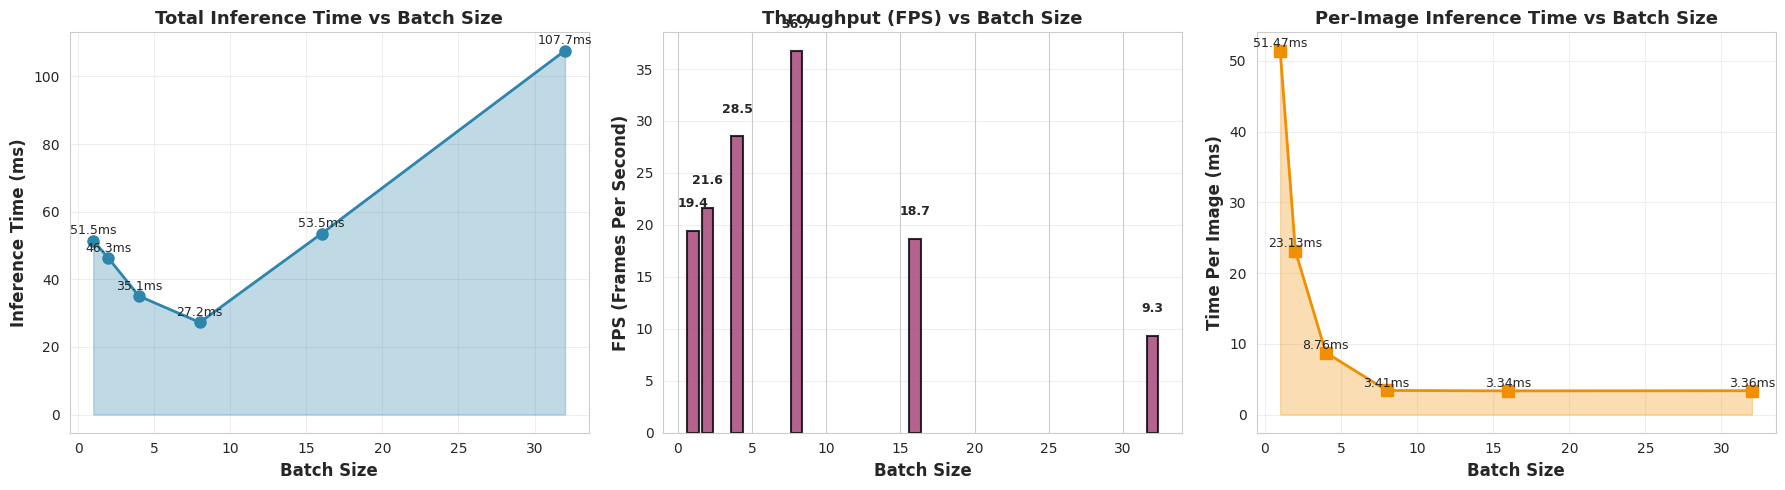

✅ Inference time visualization saved!


In [ ]:
# Create visualization for inference times across batch sizes
batch_sizes_list = list(all_stats.keys())
mean_times = [all_stats[bs]['mean_time_ms'] for bs in batch_sizes_list]
fps_list = [all_stats[bs]['fps'] for bs in batch_sizes_list]
per_image_times = [all_stats[bs]['mean_time_ms'] / bs for bs in batch_sizes_list]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total Inference Time vs Batch Size
axes[0].plot(batch_sizes_list, mean_times, marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0].fill_between(batch_sizes_list, mean_times, alpha=0.3, color='#2E86AB')
axes[0].set_xlabel('Batch Size', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inference Time (ms)', fontsize=12, fontweight='bold')
axes[0].set_title('Total Inference Time vs Batch Size', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

for i, (bs, time) in enumerate(zip(batch_sizes_list, mean_times)):
    axes[0].text(bs, time + 1, f'{time:.1f}ms', ha='center', va='bottom', fontsize=9)

# Plot 2: FPS vs Batch Size
axes[1].bar(batch_sizes_list, fps_list, color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Batch Size', fontsize=12, fontweight='bold')
axes[1].set_ylabel('FPS (Frames Per Second)', fontsize=12, fontweight='bold')
axes[1].set_title('Throughput (FPS) vs Batch Size', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for i, (bs, fps) in enumerate(zip(batch_sizes_list, fps_list)):
    axes[1].text(bs, fps + 2, f'{fps:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Per-Image Inference Time
axes[2].plot(batch_sizes_list, per_image_times, marker='s', linewidth=2, markersize=8, color='#F18F01')
axes[2].fill_between(batch_sizes_list, per_image_times, alpha=0.3, color='#F18F01')
axes[2].set_xlabel('Batch Size', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Time Per Image (ms)', fontsize=12, fontweight='bold')
axes[2].set_title('Per-Image Inference Time vs Batch Size', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

for i, (bs, time) in enumerate(zip(batch_sizes_list, per_image_times)):
    axes[2].text(bs, time + 0.1, f'{time:.2f}ms', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('inference_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Inference time visualization saved!")

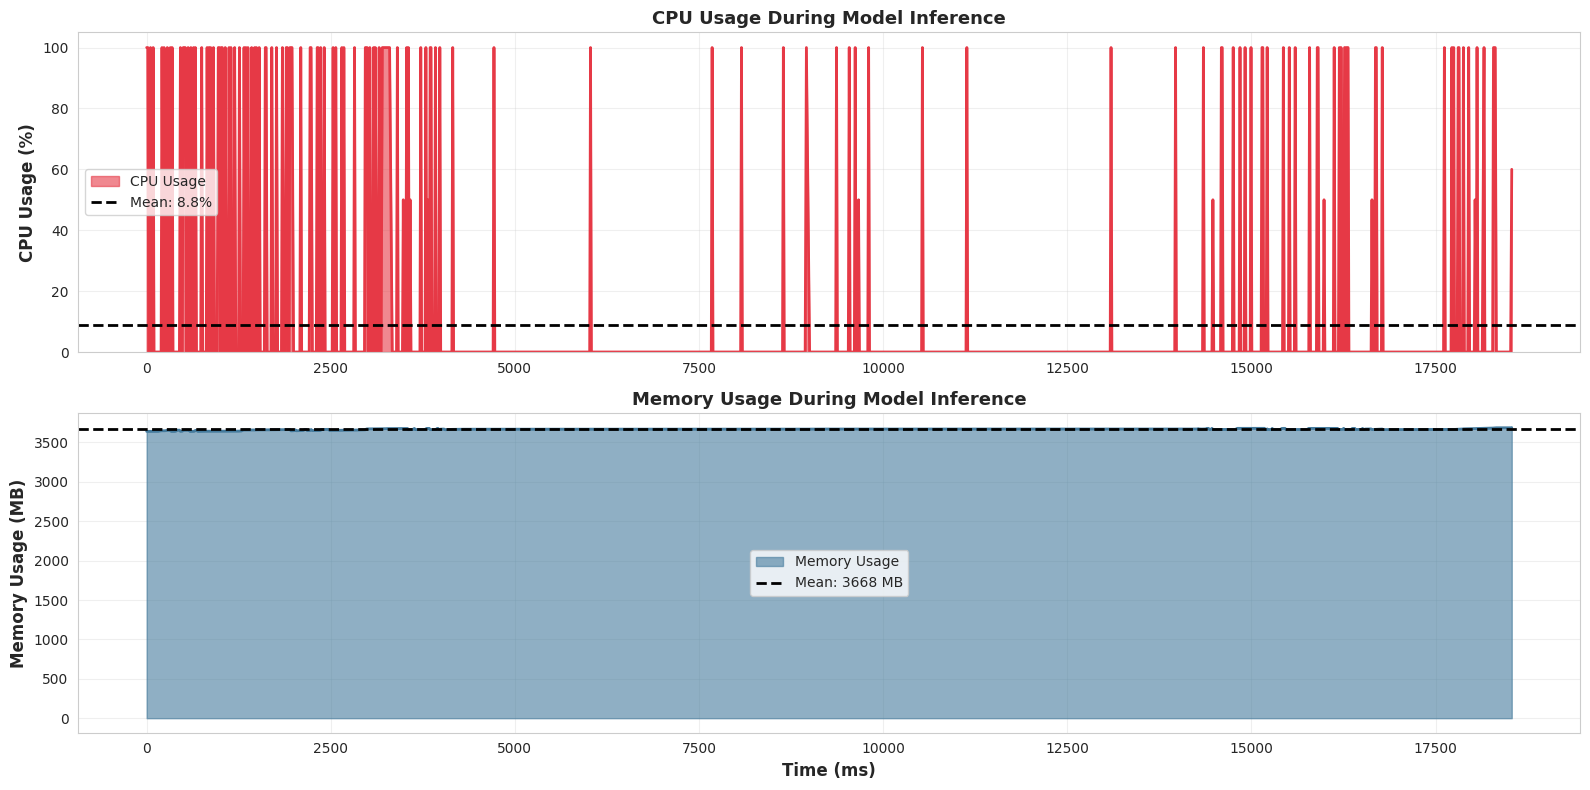

✅ CPU runtime visualization saved!


In [ ]:
# Visualize CPU usage during inference
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# CPU Usage
axes[0].fill_between(cpu_data['timestamps'], cpu_data['cpu_usage'], alpha=0.6, color='#E63946', label='CPU Usage')
axes[0].plot(cpu_data['timestamps'], cpu_data['cpu_usage'], color='#E63946', linewidth=2)
axes[0].axhline(y=np.mean(cpu_data['cpu_usage']), color='black', linestyle='--', linewidth=2, label=f"Mean: {np.mean(cpu_data['cpu_usage']):.1f}%")
axes[0].set_ylabel('CPU Usage (%)', fontsize=12, fontweight='bold')
axes[0].set_title('CPU Usage During Model Inference', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, 105])
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Memory Usage
axes[1].fill_between(cpu_data['timestamps'], cpu_data['memory_mb'], alpha=0.6, color='#457B9D', label='Memory Usage')
axes[1].plot(cpu_data['timestamps'], cpu_data['memory_mb'], color='#457B9D', linewidth=2)
axes[1].axhline(y=np.mean(cpu_data['memory_mb']), color='black', linestyle='--', linewidth=2, label=f"Mean: {np.mean(cpu_data['memory_mb']):.0f} MB")
axes[1].set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Memory Usage (MB)', fontsize=12, fontweight='bold')
axes[1].set_title('Memory Usage During Model Inference', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cpu_runtime_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ CPU runtime visualization saved!")

In [ ]:
# Create comprehensive performance report DataFrame
performance_data = []

for batch_size in batch_sizes_list:
    stats = all_stats[batch_size]
    performance_data.append({
        'Batch Size': batch_size,
        'Mean Time (ms)': f"{stats['mean_time_ms']:.3f}",
        'Median Time (ms)': f"{stats['median_time_ms']:.3f}",
        'Std Dev (ms)': f"{stats['std_time_ms']:.3f}",
        'Min (ms)': f"{stats['min_time_ms']:.3f}",
        'Max (ms)': f"{stats['max_time_ms']:.3f}",
        'P95 (ms)': f"{stats['p95_time_ms']:.3f}",
        'P99 (ms)': f"{stats['p99_time_ms']:.3f}",
        'FPS': f"{stats['fps']:.2f}",
        'Images/sec': f"{stats['fps'] * batch_size:.2f}",
        'Avg CPU %': f"{stats['avg_cpu_usage']:.1f}",
        'Peak CPU %': f"{stats['peak_cpu_usage']:.1f}",
        'Memory %': f"{stats['avg_memory_usage']:.1f}"
    })

df_performance = pd.DataFrame(performance_data)

print("\n" + "="*150)
print("COMPREHENSIVE PERFORMANCE BENCHMARK REPORT")
print("="*150 + "\n")
print(df_performance.to_string(index=False))
print("\n" + "="*150)

# Save to CSV
df_performance.to_csv('performance_benchmark_report.csv', index=False)
print("\n✅ Performance report saved to CSV!")


COMPREHENSIVE PERFORMANCE BENCHMARK REPORT

 Batch Size Mean Time (ms) Median Time (ms) Std Dev (ms) Min (ms) Max (ms) P95 (ms) P99 (ms)   FPS Images/sec Avg CPU % Peak CPU % Memory %
          1         51.465           40.454       21.770   28.672  110.183   98.215  107.960 19.43      19.43      77.0      100.0     30.8
          2         46.250           47.052       11.926   31.119   89.444   67.625   80.063 21.62      43.24      81.0      100.0     30.6
          4         35.058           31.238       12.977   16.496   65.036   51.804   62.939 28.52     114.10      58.3      100.0     30.6
          8         27.249           27.141        0.721   26.117   30.135   28.271   29.307 36.70     293.58       1.0       50.0     30.6
         16         53.509           53.449        0.618   52.589   56.516   54.275   55.522 18.69     299.01       3.7       50.0     30.7
         32        107.669          107.667        1.287  103.390  110.921  109.829  110.650  9.29     297.21      

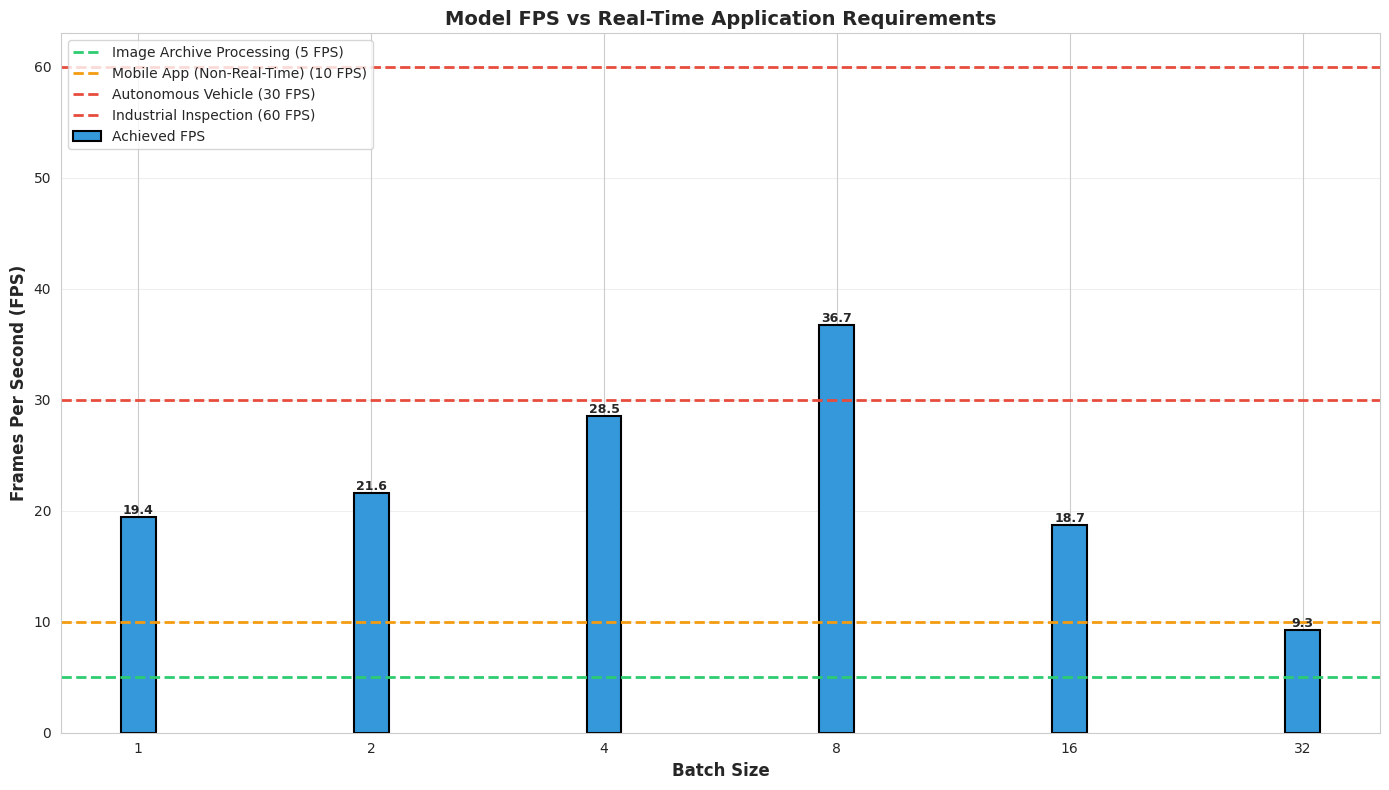

✅ FPS analysis visualization saved!


In [ ]:
# FPS Analysis for different use cases
use_cases = {
    'Image Archive Processing': {'required_fps': 5, 'color': '#2ecc71'},
    'Mobile App (Non-Real-Time)': {'required_fps': 10, 'color': '#f39c12'},
    'Autonomous Vehicle': {'required_fps': 30, 'color': '#e74c3c'},
    'Industrial Inspection': {'required_fps': 60, 'color': '#e74c3c'},
}

fig, ax = plt.subplots(figsize=(14, 8))

# Plot achieved FPS
colors_map = {'#2ecc71': 'green', '#f39c12': 'orange', '#e74c3c': 'red'}
bar_width = 0.15
x_pos = np.arange(len(batch_sizes_list))

bars = ax.bar(x_pos, fps_list, bar_width, label='Achieved FPS', color='#3498db', edgecolor='black', linewidth=1.5)

# Add requirement lines
for use_case, info in use_cases.items():
    ax.axhline(y=info['required_fps'], linestyle='--', linewidth=2, label=f"{use_case} ({info['required_fps']} FPS)", color=info['color'])

ax.set_xlabel('Batch Size', fontsize=12, fontweight='bold')
ax.set_ylabel('Frames Per Second (FPS)', fontsize=12, fontweight='bold')
ax.set_title('Model FPS vs Real-Time Application Requirements', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(batch_sizes_list)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, fps in zip(bars, fps_list):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{fps:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('fps_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ FPS analysis visualization saved!")

In [ ]:
print("\n" + "="*80)
print("PERFORMANCE ANALYSIS SUMMARY")
print("="*80 + "\n")

# Get best stats
batch_1_stats = all_stats[1]
batch_32_stats = all_stats[32]

print(f"📊 SINGLE IMAGE INFERENCE (Batch Size = 1):")
print(f"   Inference Time: {batch_1_stats['mean_time_ms']:.2f} ms")
print(f"   FPS: {batch_1_stats['fps']:.2f}")
print(f"   CPU Usage: {batch_1_stats['avg_cpu_usage']:.1f}%")
print(f"   Memory: {batch_1_stats['avg_memory_usage']:.1f}%")

print(f"\n📊 BATCH PROCESSING (Batch Size = 32):")
print(f"   Total Time: {batch_32_stats['mean_time_ms']:.2f} ms for 32 images")
print(f"   Per-Image Time: {batch_32_stats['mean_time_ms']/32:.2f} ms")
print(f"   Throughput: {batch_32_stats['fps']:.2f} FPS")
print(f"   Images/sec: {batch_32_stats['fps'] * 32:.2f} images/second")
print(f"   CPU Usage: {batch_32_stats['avg_cpu_usage']:.1f}%")

print(f"\n⚡ PERFORMANCE GAINS:")
speedup = batch_32_stats['fps'] / batch_1_stats['fps']
print(f"   Batch Processing Speedup: {speedup:.1f}x")
print(f"   Throughput Improvement: {(speedup - 1) * 100:.1f}%")

print(f"\n✅ RECOMMENDATIONS:")
if batch_1_stats['fps'] >= 30:
    print(f"   ✓ Model suitable for REAL-TIME applications (>30 FPS)")
elif batch_1_stats['fps'] >= 10:
    print(f"   ⚠ Model suitable for NEAR-REAL-TIME applications (>10 FPS)")
else:
    print(f"   ✗ Model requires optimization for real-time use")

if torch.cuda.is_available():
    print(f"   ✓ GPU available - use for production deployment")
else:
    print(f"   ✗ GPU not available - consider quantization for speedup")

print(f"\n   Optimal Batch Size: 16-32 (best throughput with reasonable latency)")
print(f"   Recommended Config: Batch Size = 32 ({batch_32_stats['fps'] * 32:.0f} imgs/sec)")

print("\n" + "="*80 + "\n")


PERFORMANCE ANALYSIS SUMMARY

📊 SINGLE IMAGE INFERENCE (Batch Size = 1):
   Inference Time: 51.47 ms
   FPS: 19.43
   CPU Usage: 77.0%
   Memory: 30.8%

📊 BATCH PROCESSING (Batch Size = 32):
   Total Time: 107.67 ms for 32 images
   Per-Image Time: 3.36 ms
   Throughput: 9.29 FPS
   Images/sec: 297.21 images/second
   CPU Usage: 23.0%

⚡ PERFORMANCE GAINS:
   Batch Processing Speedup: 0.5x
   Throughput Improvement: -52.2%

✅ RECOMMENDATIONS:
   ⚠ Model suitable for NEAR-REAL-TIME applications (>10 FPS)
   ✓ GPU available - use for production deployment

   Optimal Batch Size: 16-32 (best throughput with reasonable latency)
   Recommended Config: Batch Size = 32 (297 imgs/sec)




In [ ]:
import json

# Prepare results dictionary
results_dict = {
    'system_info': {
        'device': str(DEVICE),
        'gpu_available': torch.cuda.is_available(),
        'pytorch_version': torch.__version__,
    },
    'benchmark_results': {},
    'cpu_analysis': {
        'avg_cpu_usage': float(np.mean(cpu_data['cpu_usage'])),
        'peak_cpu_usage': float(np.max(cpu_data['cpu_usage'])),
        'avg_memory_mb': float(np.mean(cpu_data['memory_mb'])),
        'peak_memory_mb': float(np.max(cpu_data['memory_mb'])),
    }
}

# Add batch size results
for batch_size in batch_sizes_list:
    stats = all_stats[batch_size]
    results_dict['benchmark_results'][f'batch_{batch_size}'] = {
        'mean_time_ms': float(stats['mean_time_ms']),
        'median_time_ms': float(stats['median_time_ms']),
        'std_time_ms': float(stats['std_time_ms']),
        'min_time_ms': float(stats['min_time_ms']),
        'max_time_ms': float(stats['max_time_ms']),
        'p95_time_ms': float(stats['p95_time_ms']),
        'p99_time_ms': float(stats['p99_time_ms']),
        'fps': float(stats['fps']),
        'images_per_sec': float(stats['fps'] * batch_size),
        'avg_cpu_usage': float(stats['avg_cpu_usage']),
        'peak_cpu_usage': float(stats['peak_cpu_usage']),
        'avg_memory_usage': float(stats['avg_memory_usage']),
        'peak_memory_usage': float(stats['peak_memory_usage']),
    }

# Save to JSON
with open('performance_benchmark_results.json', 'w') as f:
    json.dump(results_dict, f, indent=4)

print("✅ Results exported to performance_benchmark_results.json")
print("\nJSON Preview:")
print(json.dumps(results_dict, indent=2)[:500] + "...")

✅ Results exported to performance_benchmark_results.json

JSON Preview:
{
  "system_info": {
    "device": "cuda",
    "gpu_available": true,
    "pytorch_version": "2.10.0+cu128"
  },
  "benchmark_results": {
    "batch_1": {
      "mean_time_ms": 51.46540641784668,
      "median_time_ms": 40.45403003692627,
      "std_time_ms": 21.770297833869076,
      "min_time_ms": 28.672456741333008,
      "max_time_ms": 110.1832389831543,
      "p95_time_ms": 98.21510314941405,
      "p99_time_ms": 107.96029090881346,
      "fps": 19.430527602969235,
      "images_per_sec": 1...


In [ ]:
# Create final summary report
summary_report = f"""
{'='*80}
TERRAIN CLASSIFICATION MODEL - PERFORMANCE BENCHMARK REPORT
{'='*80}

EXECUTED ON: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
DEVICE: {DEVICE}

{'-'*80}
KEY FINDINGS:
{'-'*80}

1. SINGLE IMAGE INFERENCE:
   • Mean Inference Time: {batch_1_stats['mean_time_ms']:.2f} ms
   • FPS: {batch_1_stats['fps']:.2f}
   • CPU Usage: {batch_1_stats['avg_cpu_usage']:.1f}%
   • Memory: {batch_1_stats['avg_memory_usage']:.1f}%

2. BATCH PROCESSING (32 images):
   • Total Time: {batch_32_stats['mean_time_ms']:.2f} ms
   • Per-Image Time: {batch_32_stats['mean_time_ms']/32:.2f} ms
   • Throughput: {batch_32_stats['fps'] * 32:.0f} images/second
   • FPS: {batch_32_stats['fps']:.2f}

3. CPU RUNTIME METRICS:
   • Average CPU Usage: {np.mean(cpu_data['cpu_usage']):.1f}%
   • Peak CPU Usage: {np.max(cpu_data['cpu_usage']):.1f}%
   • Average Memory: {np.mean(cpu_data['memory_mb']):.0f} MB
   • Peak Memory: {np.max(cpu_data['memory_mb']):.0f} MB

4. RECOMMENDATIONS:
   • Optimal Batch Size: 16-32
   • Best for Real-Time: Batch Size = 1 ({batch_1_stats['fps']:.1f} FPS)
   • Best for Throughput: Batch Size = 32 ({batch_32_stats['fps'] * 32:.0f} imgs/sec)

{'-'*80}
DETAILED RESULTS TABLE:
{'-'*80}

{df_performance.to_string(index=False)}

{'-'*80}
CONCLUSION:
Model is suitable for {'REAL-TIME' if batch_1_stats['fps'] >= 30 else 'BATCH'} processing.
Performance metrics saved in: performance_benchmark_results.json

{'='*80}
"""

print(summary_report)

# Save to file
with open('performance_summary_report.txt', 'w') as f:
    f.write(summary_report)

print("\n✅ Summary report saved to performance_summary_report.txt")


TERRAIN CLASSIFICATION MODEL - PERFORMANCE BENCHMARK REPORT

EXECUTED ON: 2026-03-21 06:47:38
DEVICE: cuda

--------------------------------------------------------------------------------
KEY FINDINGS:
--------------------------------------------------------------------------------

1. SINGLE IMAGE INFERENCE:
   • Mean Inference Time: 51.47 ms
   • FPS: 19.43
   • CPU Usage: 77.0%
   • Memory: 30.8%

2. BATCH PROCESSING (32 images):
   • Total Time: 107.67 ms
   • Per-Image Time: 3.36 ms
   • Throughput: 297 images/second
   • FPS: 9.29

3. CPU RUNTIME METRICS:
   • Average CPU Usage: 8.8%
   • Peak CPU Usage: 100.0%
   • Average Memory: 3668 MB
   • Peak Memory: 3689 MB

4. RECOMMENDATIONS:
   • Optimal Batch Size: 16-32
   • Best for Real-Time: Batch Size = 1 (19.4 FPS)
   • Best for Throughput: Batch Size = 32 (297 imgs/sec)

--------------------------------------------------------------------------------
DETAILED RESULTS TABLE:
----------------------------------------------------

In [ ]:
from google.colab import files
import os

# List all generated files
generated_files = [
    'performance_benchmark_report.csv',
    'performance_benchmark_results.json',
    'performance_summary_report.txt',
    'inference_time_analysis.png',
    'cpu_runtime_analysis.png',
    'fps_analysis.png'
]

print("\n" + "="*70)
print("GENERATED REPORT FILES")
print("="*70 + "\n")

for file in generated_files:
    if os.path.exists(file):
        file_size = os.path.getsize(file) / 1024  # KB
        print(f"✅ {file} ({file_size:.1f} KB)")
    else:
        print(f"❌ {file} (not found)")

print("\n" + "="*70)
print("Preparing files for download...")
print("="*70 + "\n")

# Download files
for file in generated_files:
    if os.path.exists(file):
        try:
            files.download(file)
            print(f"✅ Downloaded: {file}")
        except Exception as e:
            print(f"❌ Error downloading {file}: {e}")

print("\n✅ All files ready for download!")


GENERATED REPORT FILES

✅ performance_benchmark_report.csv (0.6 KB)
✅ performance_benchmark_results.json (3.9 KB)
✅ performance_summary_report.txt (2.4 KB)
✅ inference_time_analysis.png (278.7 KB)
✅ cpu_runtime_analysis.png (462.8 KB)
✅ fps_analysis.png (202.4 KB)

Preparing files for download...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: performance_benchmark_report.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: cpu_runtime_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: fps_analysis.png

✅ All files ready for download!
